In [1]:
## conda activate gpy_torch_env
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import tqdm
import torch 
from torch.autograd.functional import jacobian
from torch.distributions.multivariate_normal import MultivariateNormal
import gpytorch
import pyro
from pyro.infer import MCMC, NUTS
import pyro.distributions as dist
from scipy.linalg import eigh
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.stats import norm, multivariate_normal, invgamma, uniform
from scipy import interpolate
import pickle



In [2]:
def posterior_metrics(posterior_samples, true_values, credibility_level=0.95):
    """
    Compute RMSE, bias, empirical coverage, and credible interval width
    from posterior samples.

    Parameters
    ----------
    posterior_samples : array-like
        Posterior samples with shape (n_samples, n_parameters)
        or (n_samples,) for a scalar parameter.

    true_values : array-like
        True parameter values with shape (n_parameters,)
        or scalar for a single parameter.

    credibility_level : float, optional
        Credible interval level. Default is 0.95.

    Returns
    -------
    metrics : dict
        Dictionary containing:
        - posterior_mean
        - rmse
        - bias
        - coverage
        - interval_width
        - lower_bound
        - upper_bound
    """

    samples = np.asarray(posterior_samples)
    true_values = np.asarray(true_values)

    # Handle scalar parameter case
    if samples.ndim == 1:
        samples = samples[:, None]
        true_values = np.asarray([true_values])

    alpha = 1.0 - credibility_level
    lower_q = 100 * alpha / 2
    upper_q = 100 * (1 - alpha / 2)

    posterior_mean = np.mean(samples, axis=0)

    lower_bound = np.percentile(samples, lower_q, axis=0)
    upper_bound = np.percentile(samples, upper_q, axis=0)

    bias = posterior_mean - true_values
    rmse = np.sqrt((posterior_mean - true_values) ** 2)

    coverage = (true_values >= lower_bound) & (true_values <= upper_bound)
    interval_width = upper_bound - lower_bound

    metrics = {
        "posterior_mean": posterior_mean,
        "bias": bias,
        "rmse": rmse,
        "coverage": coverage.astype(float),
        "interval_width": interval_width,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
    }

    return metrics

In [3]:
with open("FourSprings_posterior_metrics.pkl", "rb") as f:
    results = pickle.load(f)
    summary = pickle.load(f)
num_par = len(summary['bias_KOH']['mean'])
for metric_name, stats in summary.items():
    print(f"\n{metric_name}")
    for par_idx in range(num_par):
        print(
            f"Parameter {par_idx}: "
            f"mean={stats['mean'][par_idx]:.4f}, "
            f"median={stats['median'][par_idx]:.4f}, "
            f"variance={stats['variance'][par_idx]:.4f}, "
            f"95% CI=({stats['ci_lower'][par_idx]:.4f}, "
            f"{stats['ci_upper'][par_idx]:.4f})"
        )

print('KOH coverage')
print(sum(results['cover_KOH'].T)/50)
print('MOP coverage')
print(sum(results['cover_MOP'].T)/50)


mean_KOH
Parameter 0: mean=46.4855, median=41.9880, variance=647.9244, 95% CI=(39.2515, 53.7196)
Parameter 1: mean=5.7521, median=6.0417, variance=2.8958, 95% CI=(5.2685, 6.2357)
Parameter 2: mean=49.9393, median=54.8291, variance=474.1755, 95% CI=(43.7507, 56.1278)
Parameter 3: mean=4.8562, median=5.1714, variance=3.3150, 95% CI=(4.3387, 5.3736)
Parameter 4: mean=49.5541, median=55.4519, variance=394.9473, 95% CI=(43.9062, 55.2020)
Parameter 5: mean=5.4613, median=5.7460, variance=1.5647, 95% CI=(5.1059, 5.8168)
Parameter 6: mean=55.5273, median=54.3652, variance=264.5028, 95% CI=(50.9052, 60.1493)
Parameter 7: mean=5.4927, median=5.7161, variance=1.6514, 95% CI=(5.1275, 5.8579)

mean_MOP
Parameter 0: mean=45.7624, median=43.3107, variance=653.1012, 95% CI=(38.4995, 53.0253)
Parameter 1: mean=5.7478, median=6.2971, variance=3.5239, 95% CI=(5.2143, 6.2813)
Parameter 2: mean=50.5864, median=57.5669, variance=503.5378, 95% CI=(44.2091, 56.9637)
Parameter 3: mean=4.9178, median=5.2140, v

In [4]:
with open("TwoSprings_posterior_metrics.pkl", "rb") as f:
    results = pickle.load(f)
    summary = pickle.load(f)
num_par = len(summary['bias_KOH']['mean'])
for metric_name, stats in summary.items():
    print(f"\n{metric_name}")
    for par_idx in range(num_par):
        print(
            f"Parameter {par_idx}: "
            f"mean={stats['mean'][par_idx]:.4f}, "
            f"median={stats['median'][par_idx]:.4f}, "
            f"variance={stats['variance'][par_idx]:.4f}, "
            f"95% CI=({stats['ci_lower'][par_idx]:.4f}, "
            f"{stats['ci_upper'][par_idx]:.4f})"
        )
print('KOH coverage')
print(sum(results['cover_KOH'].T)/50)
print('MOP coverage')
print(sum(results['cover_MOP'].T)/50)


mean_KOH
Parameter 0: mean=48.5795, median=47.1840, variance=805.7306, 95% CI=(40.5125, 56.6466)
Parameter 1: mean=5.6111, median=6.0751, variance=5.0722, 95% CI=(4.9710, 6.2512)
Parameter 2: mean=50.2111, median=50.7390, variance=576.0520, 95% CI=(43.3901, 57.0321)
Parameter 3: mean=4.9558, median=5.4227, variance=6.7434, 95% CI=(4.2178, 5.6938)

mean_MOP
Parameter 0: mean=48.4022, median=47.0481, variance=833.4165, 95% CI=(40.1977, 56.6066)
Parameter 1: mean=5.5131, median=5.9465, variance=5.6186, 95% CI=(4.8395, 6.1868)
Parameter 2: mean=49.8185, median=51.0236, variance=589.6922, 95% CI=(42.9171, 56.7198)
Parameter 3: mean=4.9423, median=5.3310, variance=7.0947, 95% CI=(4.1853, 5.6993)

bias_KOH
Parameter 0: mean=0.2540, median=0.5814, variance=34.7233, 95% CI=(-1.4207, 1.9287)
Parameter 1: mean=0.3030, median=0.2404, variance=1.0415, 95% CI=(0.0129, 0.5930)
Parameter 2: mean=1.1032, median=0.7649, variance=58.4047, 95% CI=(-1.0687, 3.2751)
Parameter 3: mean=0.0451, median=0.1266,

In [5]:
with open("SIRV_IRV_posterior_metrics_V2.pkl", "rb") as f:
    results = pickle.load(f)
    summary = pickle.load(f)
num_par = len(summary['bias_KOH']['mean'])
for metric_name, stats in summary.items():
    print(f"\n{metric_name}")
    for par_idx in range(num_par):
        print(
            f"Parameter {par_idx}: "
            f"mean={stats['mean'][par_idx]:.4f}, "
            f"median={stats['median'][par_idx]:.4f}, "
            f"variance={stats['variance'][par_idx]:.4f}, "
            f"95% CI=({stats['ci_lower'][par_idx]:.4f}, "
            f"{stats['ci_upper'][par_idx]:.4f})"
        )
print('KOH coverage')
print(sum(results['cover_KOH'].T)/50)
print('MOP coverage')
print(sum(results['cover_MOP'].T)/50)


mean_KOH
Parameter 0: mean=11.8783, median=11.7575, variance=3.9130, 95% CI=(11.3161, 12.4405)
Parameter 1: mean=0.5741, median=0.5985, variance=0.0573, 95% CI=(0.5060, 0.6421)
Parameter 2: mean=0.6371, median=0.6752, variance=0.0508, 95% CI=(0.5731, 0.7011)
Parameter 3: mean=0.5023, median=0.5057, variance=0.0480, 95% CI=(0.4400, 0.5646)
Parameter 4: mean=0.5149, median=0.5341, variance=0.0459, 95% CI=(0.4541, 0.5758)

mean_MOP
Parameter 0: mean=11.8886, median=11.6808, variance=4.1083, 95% CI=(11.3126, 12.4646)
Parameter 1: mean=0.5735, median=0.5947, variance=0.0628, 95% CI=(0.5023, 0.6447)
Parameter 2: mean=0.6397, median=0.7054, variance=0.0562, 95% CI=(0.5723, 0.7071)
Parameter 3: mean=0.4993, median=0.4895, variance=0.0597, 95% CI=(0.4299, 0.5687)
Parameter 4: mean=0.5166, median=0.5135, variance=0.0551, 95% CI=(0.4499, 0.5833)

bias_KOH
Parameter 0: mean=-0.0055, median=0.0418, variance=0.1594, 95% CI=(-0.1190, 0.1079)
Parameter 1: mean=0.0000, median=0.0086, variance=0.0026, 

In [6]:
with open("SIRV_IV_posterior_metrics_V2.pkl", "rb") as f:
    results = pickle.load(f)
    summary = pickle.load(f)
num_par = len(summary['bias_KOH']['mean'])
for metric_name, stats in summary.items():
    print(f"\n{metric_name}")
    for par_idx in range(num_par):
        print(
            f"Parameter {par_idx}: "
            f"mean={stats['mean'][par_idx]:.4f}, "
            f"median={stats['median'][par_idx]:.4f}, "
            f"variance={stats['variance'][par_idx]:.4f}, "
            f"95% CI=({stats['ci_lower'][par_idx]:.4f}, "
            f"{stats['ci_upper'][par_idx]:.4f})"
        )
print('KOH coverage')
print(sum(results['cover_KOH'].T)/50)
print('MOP coverage')
print(sum(results['cover_MOP'].T)/50)


mean_KOH
Parameter 0: mean=5.0126, median=4.4905, variance=4.8738, 95% CI=(4.3852, 5.6400)
Parameter 1: mean=0.5270, median=0.5816, variance=0.0661, 95% CI=(0.4539, 0.6000)
Parameter 2: mean=0.5446, median=0.5485, variance=0.0255, 95% CI=(0.4992, 0.5899)
Parameter 3: mean=0.5269, median=0.5226, variance=0.0033, 95% CI=(0.5105, 0.5434)
Parameter 4: mean=0.4680, median=0.4870, variance=0.0458, 95% CI=(0.4071, 0.5288)

mean_MOP
Parameter 0: mean=5.1423, median=4.4162, variance=5.0245, 95% CI=(4.5052, 5.7793)
Parameter 1: mean=0.5285, median=0.5247, variance=0.0737, 95% CI=(0.4513, 0.6057)
Parameter 2: mean=0.5454, median=0.5474, variance=0.0312, 95% CI=(0.4952, 0.5955)
Parameter 3: mean=0.4969, median=0.5044, variance=0.0090, 95% CI=(0.4700, 0.5239)
Parameter 4: mean=0.4787, median=0.4716, variance=0.0611, 95% CI=(0.4084, 0.5490)

bias_KOH
Parameter 0: mean=-1.1414, median=-0.6320, variance=1.8900, 95% CI=(-1.5321, -0.7507)
Parameter 1: mean=0.0072, median=0.0070, variance=0.0057, 95% CI

In [7]:
with open("Fitz_posterior_metrics_V2.pkl", "rb") as f:
    results = pickle.load(f)
    summary = pickle.load(f)
num_par = len(summary['bias_KOH']['mean'])
for metric_name, stats in summary.items():
    print(f"\n{metric_name}")
    for par_idx in range(num_par):
        print(
            f"Parameter {par_idx}: "
            f"mean={stats['mean'][par_idx]:.4f}, "
            f"median={stats['median'][par_idx]:.4f}, "
            f"variance={stats['variance'][par_idx]:.4f}, "
            f"95% CI=({stats['ci_lower'][par_idx]:.4f}, "
            f"{stats['ci_upper'][par_idx]:.4f})"
        )
print('KOH coverage')
print(sum(results['cover_KOH'].T)/50)
print('MOP coverage')
print(sum(results['cover_MOP'].T)/50)


mean_KOH
Parameter 0: mean=0.5367, median=0.5106, variance=0.0474, 95% CI=(0.4748, 0.5985)
Parameter 1: mean=0.5748, median=0.5949, variance=0.0318, 95% CI=(0.5242, 0.6255)
Parameter 2: mean=17.3942, median=16.9881, variance=13.4476, 95% CI=(16.3520, 18.4363)
Parameter 3: mean=0.5103, median=0.4909, variance=0.0537, 95% CI=(0.4444, 0.5762)

mean_MOP
Parameter 0: mean=0.5397, median=0.5243, variance=0.0554, 95% CI=(0.4728, 0.6066)
Parameter 1: mean=0.5802, median=0.5904, variance=0.0374, 95% CI=(0.5252, 0.6352)
Parameter 2: mean=17.2841, median=17.1452, variance=14.4380, 95% CI=(16.2042, 18.3640)
Parameter 3: mean=0.5205, median=0.4976, variance=0.0660, 95% CI=(0.4475, 0.5935)

bias_KOH
Parameter 0: mean=0.0082, median=0.0175, variance=0.0174, 95% CI=(-0.0294, 0.0457)
Parameter 1: mean=-0.0157, median=-0.0187, variance=0.0420, 95% CI=(-0.0740, 0.0426)
Parameter 2: mean=0.0379, median=-0.1458, variance=3.2491, 95% CI=(-0.4744, 0.5502)
Parameter 3: mean=-0.0094, median=0.0065, variance=0

(50, 4)
4


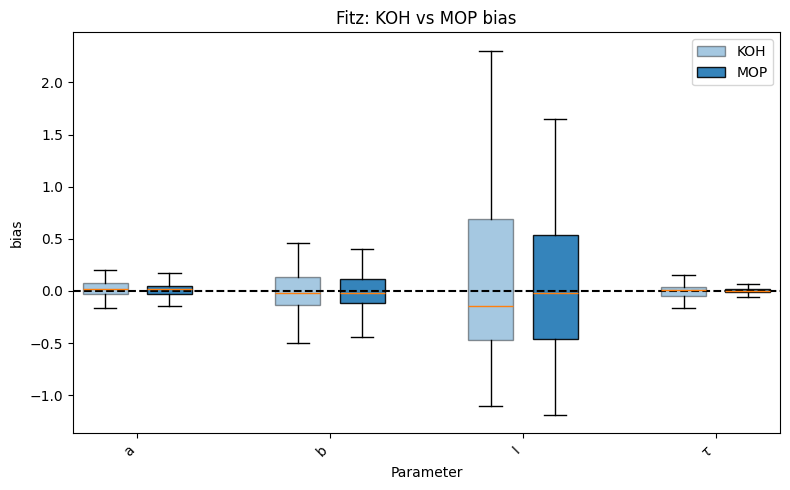

(50, 4)
4


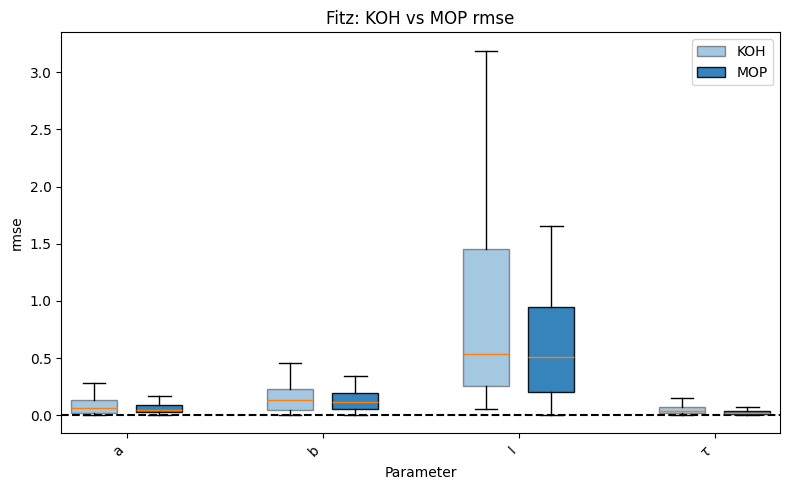

(50, 4)
4


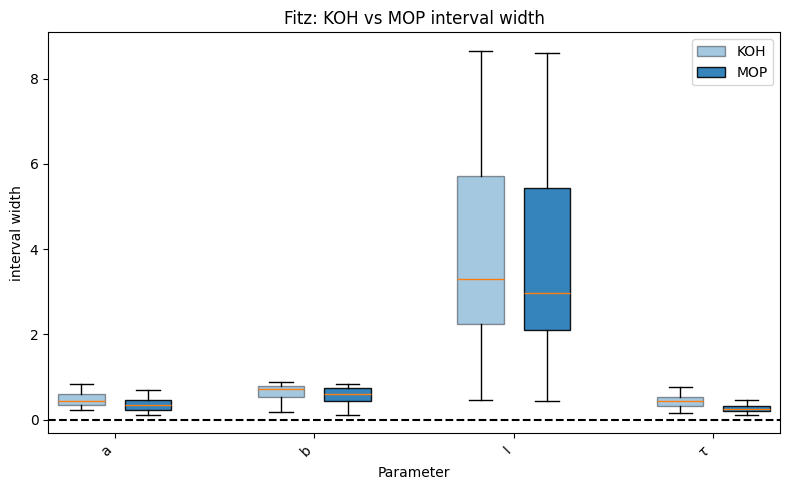

In [35]:
from pathlib import Path
metric_files = {
    # "FourSprings": "FourSprings_posterior_metrics.pkl",
    # "TwoSprings": "TwoSprings_posterior_metrics.pkl",
    # "SIRV_IRV": "SIRV_IRV_posterior_metrics_V2.pkl",
    # "SIRV_IV": "SIRV_IV_posterior_metrics_V2.pkl",
    "Fitz": "Fitz_posterior_metrics_V2.pkl",
}

metrics_to_compare = {
    "bias": ("bias_KOH", "bias_MOP"),
    "rmse": ("RMSE_KOH", "RMSE_MOP"),
    "interval width": ("int_wid_KOH", "int_wid_MOP"),
}

parameter_names = {
    "FourSprings": ('k1','c1','k2','c2','k3','c3','k4','c4'),
    "TwoSprings": ('k1','c1','k2','c2'),
    "SIRV_IRV": ('a','v',r'$mu$','wr','wv'),
    "SIRV_IV": ('a','v',r'$mu$','wr','wv'),
    "Fitz": ('a','b','I',r'$\tau$'),
    
    
}

def load_metric_file(filename):
    """
    Each pickle file contains:
        1. results dictionary
        2. summary dictionary
    """
    with open(filename, "rb") as f:
        results = pickle.load(f)
        summary = pickle.load(f)
    return results, summary

def as_2d_array(x):
    """
    Convert arrays to shape:
        n_replicates x n_parameters
    """
    arr = np.asarray(x)

    if arr.ndim == 1:
        arr = arr[:, None]

    return arr

def compare_koh_mop_boxplots(
    results,
    system_name,
    metric_label,
    koh_key,
    mop_key,
    param_names,
    save_dir="koh_vs_mop_boxplots"
):
    """
    Create one figure comparing KOH and MOP for a single metric
    within a single loaded file.
    """
    if koh_key not in results or mop_key not in results:
        print(f"Skipping {system_name} - {metric_label}: missing {koh_key} or {mop_key}")
        return

    koh_values = as_2d_array(results[koh_key]).T
    mop_values = as_2d_array(results[mop_key]).T

    print(np.shape(koh_values))

    if koh_values.shape[1] != mop_values.shape[1]:
        print(
            f"Skipping {system_name} - {metric_label}: "
            f"KOH has {koh_values.shape[1]} parameters, "
            f"MOP has {mop_values.shape[1]} parameters"
        )
        return

    n_params = koh_values.shape[1]
    print(n_params)

    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)

    data = []
    positions = []
    labels = []

    for param_idx in range(n_params):
        base_position = param_idx * 3

        data.append(koh_values[:, param_idx])
        positions.append(base_position)

        data.append(mop_values[:, param_idx])
        positions.append(base_position + 1)

        labels.append(f"{param_names[param_idx]}")

    plt.figure(figsize=(max(8, 1.8 * n_params), 5))

    box = plt.boxplot(
        data,
        positions=positions,
        widths=0.7,
        patch_artist=True,
        showmeans=False,
        showfliers=False    
        )

    for i, patch in enumerate(box["boxes"]):
        if i % 2 == 0:
            patch.set_alpha(0.4)
            patch.set_label("KOH" if i == 0 else "")
        else:
            patch.set_alpha(0.9)
            patch.set_label("MOP" if i == 1 else "")

    xtick_positions = [param_idx * 3 + 0.5 for param_idx in range(n_params)]

    plt.xticks(
        xtick_positions,
        labels,
        rotation=45,
        ha="right"
    )

    plt.title(f"{system_name}: KOH vs MOP {metric_label}")
    plt.xlabel("Parameter")
    plt.axhline(y=0,color='black',linestyle='--')
    plt.ylabel(metric_label)

    handles = [
        box["boxes"][0],
        box["boxes"][1],
    ]
    plt.legend(handles, ["KOH", "MOP"])

    plt.tight_layout()

    output_file = save_dir / f"{system_name}_{metric_label}_KOH_vs_MOP_boxplot.png"
    # plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

def plot_all_koh_mop_metric_comparisons(metric_files, metrics_to_compare):
    """
    For each loaded file, create separate figures for:
        bias
        RMSE
        coverage
    """
    for system_name, filename in metric_files.items():
        results, summary = load_metric_file(filename)


        param_labels = parameter_names[system_name]    
        for metric_label, (koh_key, mop_key) in metrics_to_compare.items():
            compare_koh_mop_boxplots(
                results=results,
                system_name=system_name,
                metric_label=metric_label,
                koh_key=koh_key,
                mop_key=mop_key,
                param_names=param_labels
            )

plot_all_koh_mop_metric_comparisons(metric_files, metrics_to_compare)